# GAIN Overlap Visualization

Empirical counterpart of `overlap_visualization.ipynb` for the real GAIN dataset.

Under the rejection-sampling induction of [docs/GAIN_experiment_plan.md](../docs/GAIN_experiment_plan.md) §3.3, the post-filter treatment propensity is
$$\pi(x) \;=\; \frac{m(x)\pi_0}{m(x)\pi_0 + (1-m(x))(1-\pi_0)},\quad m(x) = \sigma(\gamma_\pi(\beta_{\text{earn}}x_{\text{earn}} + \beta_{\text{age}}x_{\text{age}})).$$
The long-term-data propensity $\rho(x) = \mathrm{P}(R=1 \mid X=x)$ is fixed by the Riverside-vs-other-sites split; it shifts with $\gamma_\pi$ only through the changing D1 covariate density.

Since we don't have analytic $\pi$ or $\rho$, we estimate:
- **$\hat\pi(x)$** = L2-logistic of $A$ on $X$, fit on the post-filter Riverside (D1).
- **$\hat\rho(x)$** = L2-logistic of $R$ on $X$, fit on D1 $\cup$ D2, with $R=0$ for D1 rows and $R=1$ for D2 rows.

Matches the fixed overlap estimator used in [scripts/evaluate_realworld.py](../scripts/evaluate_realworld.py).

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from omegaconf import OmegaConf
from scipy.stats import gaussian_kde
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from src.data.gain import RealWorldGAIN, X_COLS

In [2]:
# --------------------------------------------------------------------------
# build_overlap(gamma, seed) -> dict with pi_hat, rho_hat, and covariate
# projections on the post-filter Riverside sample (D1).
# --------------------------------------------------------------------------
AGE_IDX = X_COLS.index('age')
EARN_IDX = [X_COLS.index(f'tcprn{i}') for i in range(1, 11)]

CONFIG_PATH = '../config/dataset/gain.yaml'


def build_overlap(gamma, seed=42, C_logit=1.0):
    cfg = OmegaConf.load(CONFIG_PATH)
    cfg.data_path = '../' + cfg.data_path
    cfg.gamma_pi = float(gamma)
    cfg.seed = int(seed)
    ds = RealWorldGAIN(cfg)

    X_d1 = np.concatenate([ds.X_train, ds.X_test], axis=0)
    A_d1 = np.concatenate([ds.A_train, ds.A_test], axis=0)
    X_d2 = ds.X_other

    scaler = StandardScaler().fit(X_d1)
    Z_d1 = scaler.transform(X_d1)
    Z_d2 = scaler.transform(X_d2)

    pi_clf = LogisticRegression(penalty='l2', C=C_logit, max_iter=2000,
                                random_state=seed).fit(Z_d1, A_d1)
    pi_hat = pi_clf.predict_proba(Z_d1)[:, 1]

    Z_all = np.concatenate([Z_d1, Z_d2], axis=0)
    R_all = np.concatenate([np.zeros(len(Z_d1)), np.ones(len(Z_d2))])
    rho_clf = LogisticRegression(penalty='l2', C=C_logit, max_iter=2000,
                                 random_state=seed).fit(Z_all, R_all)
    rho_hat = rho_clf.predict_proba(Z_d1)[:, 1]

    x_earn_raw = X_d1[:, EARN_IDX].mean(axis=1)
    x_age_raw = X_d1[:, AGE_IDX]
    x_earn = (x_earn_raw - x_earn_raw.mean()) / (x_earn_raw.std() + 1e-12)
    x_age = (x_age_raw - x_age_raw.mean()) / (x_age_raw.std() + 1e-12)

    return {
        'gamma': float(gamma),
        'pi': pi_hat, 'rho': rho_hat,
        'x_earn': x_earn, 'x_age': x_age,
        'A': A_d1, 'n_d1': len(X_d1),
    }


def binned_mean(x, y, n_bins=15):
    """Equal-count bins: returns (x_centers, y_means, y_stds)."""
    order = np.argsort(x)
    xs, ys = x[order], y[order]
    edges = np.linspace(0, len(x), n_bins + 1, dtype=int)
    xc = np.array([xs[edges[i]:edges[i+1]].mean() for i in range(n_bins)])
    ym = np.array([ys[edges[i]:edges[i+1]].mean() for i in range(n_bins)])
    ys_ = np.array([ys[edges[i]:edges[i+1]].std() for i in range(n_bins)])
    return xc, ym, ys_

## 1. Overlap vs. covariates across a range of $\gamma_\pi$

Binned means of $\hat\pi(x)(1-\hat\pi(x))$ and $\hat\rho(x)$ against the two covariates driving $m(x)$: standardized pre-RA earnings and standardized age.

As $\gamma_\pi$ grows, treatment overlap ($\pi(1-\pi)$) should collapse to 0 in the high-earn / high-age corner (where $m(x) \to 1$) and symmetrically in the opposite corner (where $m(x) \to 0$). $\hat\rho(x)$ is nearly flat across $\gamma_\pi$ because the D1/D2 split is site-based, not $\gamma_\pi$-based.

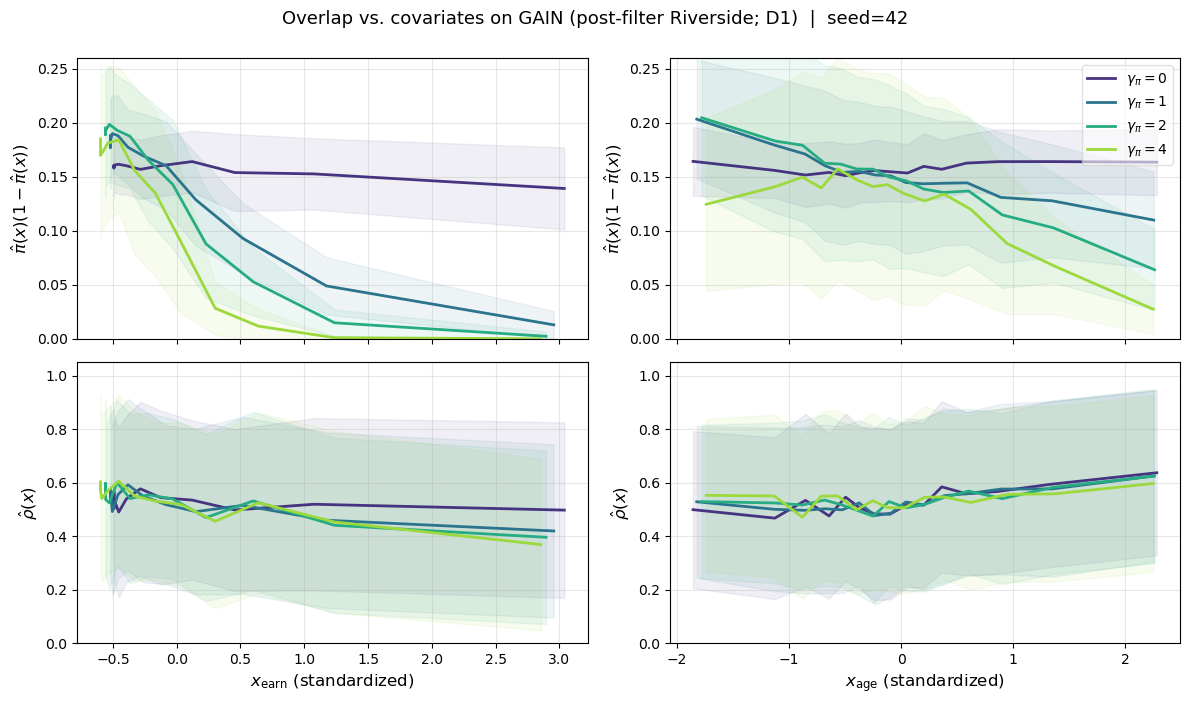

In [3]:
GAMMA_SWEEP = [0.0, 1.0, 2.0, 4.0]
SEED = 42

results = {g: build_overlap(g, seed=SEED) for g in GAMMA_SWEEP}

CMAP = plt.cm.viridis
colors = [CMAP(v) for v in np.linspace(0.15, 0.85, len(GAMMA_SWEEP))]

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex='col')

metrics = [
    ('pi_var', r'$\hat\pi(x)(1-\hat\pi(x))$', lambda d: d['pi'] * (1 - d['pi']), (0, 0.26)),
    ('rho',    r'$\hat\rho(x)$',              lambda d: d['rho'],                 (0, 1.05)),
]
covariates = [('x_earn', r'$x_\mathrm{earn}$ (standardized)'),
              ('x_age',  r'$x_\mathrm{age}$ (standardized)')]

for row, (mname, ylabel, getter, ylim) in enumerate(metrics):
    for col, (xname, xlabel) in enumerate(covariates):
        ax = axes[row, col]
        for g, color in zip(GAMMA_SWEEP, colors):
            d = results[g]
            xc, ym, ys_ = binned_mean(d[xname], getter(d), n_bins=15)
            ax.plot(xc, ym, color=color, lw=2.0, label=rf'$\gamma_\pi={g:g}$')
            ax.fill_between(xc, ym - ys_, ym + ys_, color=color, alpha=0.08)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.set_ylim(*ylim)
        if row == 1:
            ax.set_xlabel(xlabel, fontsize=12)
        if row == 0 and col == 1:
            ax.legend(fontsize=10, framealpha=0.6, loc='upper right')
        ax.grid(alpha=0.3)

plt.suptitle(r'Overlap vs. covariates on GAIN (post-filter Riverside; D1)  |  seed=' + str(SEED),
             fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig('gain_overlap_vs_covariates.pdf', bbox_inches='tight')
plt.show()

## 2. KDE of $\hat\pi(x)(1-\hat\pi(x))$ and $\hat\rho(x)$ for a fixed $\gamma_\pi$

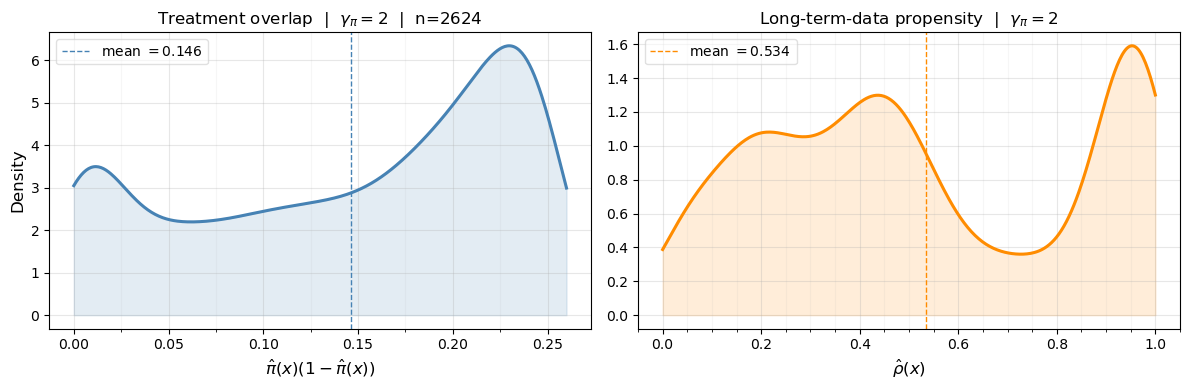

In [4]:
GAMMA_KDE = 2.0

d = results.get(GAMMA_KDE) or build_overlap(GAMMA_KDE, seed=SEED)
pi_var = d['pi'] * (1 - d['pi'])
rho = d['rho']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

grid_pi = np.linspace(0, 0.26, 400)
kde_pi = gaussian_kde(pi_var, bw_method='scott')
ax = axes[0]
ax.plot(grid_pi, kde_pi(grid_pi), color='steelblue', lw=2.2)
ax.fill_between(grid_pi, kde_pi(grid_pi), alpha=0.15, color='steelblue')
ax.axvline(pi_var.mean(), color='steelblue', ls='--', lw=1.0,
           label=rf'mean $={pi_var.mean():.3f}$')
ax.set_xlabel(r'$\hat\pi(x)(1-\hat\pi(x))$', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(rf'Treatment overlap  |  $\gamma_\pi={GAMMA_KDE:g}$  |  n={d["n_d1"]}', fontsize=12)
ax.legend(fontsize=10, framealpha=0.6)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.025))
ax.grid(which='major', alpha=0.3)
ax.grid(which='minor', alpha=0.1)

grid_rho = np.linspace(0, 1, 400)
kde_rho = gaussian_kde(rho, bw_method='scott')
ax = axes[1]
ax.plot(grid_rho, kde_rho(grid_rho), color='darkorange', lw=2.2)
ax.fill_between(grid_rho, kde_rho(grid_rho), alpha=0.15, color='darkorange')
ax.axvline(rho.mean(), color='darkorange', ls='--', lw=1.0,
           label=rf'mean $={rho.mean():.3f}$')
ax.set_xlabel(r'$\hat\rho(x)$', fontsize=12)
ax.set_title(rf'Long-term-data propensity  |  $\gamma_\pi={GAMMA_KDE:g}$', fontsize=12)
ax.legend(fontsize=10, framealpha=0.6)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.05))
ax.grid(which='major', alpha=0.3)
ax.grid(which='minor', alpha=0.1)

plt.tight_layout()
plt.savefig(f'gain_kde_overlap_gamma{int(GAMMA_KDE)}.pdf', bbox_inches='tight')
plt.show()